# Exploratory Data Analysis

This is the second part of the Data Science hiring assessment. The assessment further develops the business question from the first interview. You are working on a case to forecast product demands. 

### Load libraries

We added a number of libraries that should help you get started with your exploratory data analysis. 

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

from utils import (
    read_demand,
    read_promotions,
    extend_promotions_days,
    merge,
    clean_demand_per_group,
    aggregate_to_weekly,
)

# Default plot style for the notebook
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

### Import Data

We provide two generated datasets with this exercise. 

The first dataset **demand.csv** represents the historic demand of three different products (SKUs) in three different supermarkets in the Netherlands. Data is available on a daily basis. 

The second **promotions.csv**, indicates different time points in which a certain SKU was on promotion in a specific supermarket. The dataset only shows the first day of the promotion period. Overall, a product is on promotion for one week.

The functions to import the data are provided as well as a function that extends the promotion data to cover the entire promotion period. 

In [2]:
# Demand data
demand_df = read_demand('./demand.csv')
demand_df.head()

,demand,sku,supermarket
date,,,
2019-01-01,93.0,desperados,albert-heijn
2019-01-02,93.0,desperados,albert-heijn
2019-01-03,94.0,desperados,albert-heijn
2019-01-04,95.0,desperados,albert-heijn
2019-01-05,92.0,desperados,albert-heijn


In [3]:
# promotion data
promotions_df = read_promotions('./promotions.csv')
promotions_df.head()

,sku,supermarket
promotion_date,,
2020-09-26,desperados,jumbo
2019-09-18,desperados,jumbo
2021-09-28,desperados,jumbo
2021-02-11,desperados,jumbo
2021-10-03,desperados,dirk


In [4]:
extended_promotions = extend_promotions_days(promotions_df, 7).drop('promotion_id', axis=1)
merge_df = merge(demand_df, extended_promotions)
merge_df.head()

,demand,sku,supermarket,promotion
date,,,,
2019-01-01,93.0,desperados,albert-heijn,False
2019-01-02,93.0,desperados,albert-heijn,False
2019-01-03,94.0,desperados,albert-heijn,False
2019-01-04,95.0,desperados,albert-heijn,False
2019-01-05,92.0,desperados,albert-heijn,False


### Part 1: Data quality
The first part of the assignment is to check the quality of the data provided and clean it if necessary.

In [5]:
# Print the size of merge_df and range of date in it
print('Rows:', merge_df.shape[0])
print('Date Range:', merge_df.index.min().date(), '->', merge_df.index.max().date())

Rows: 9855
Date Range: 2019-01-01 -> 2021-12-30


In [6]:
# Per-group day counts in merge_df
print(merge_df.groupby(['sku', 'supermarket']).size().rename('days').to_frame())

                               days
sku              supermarket       
desperados       albert-heijn  1095
                 dirk          1095
                 jumbo         1095
heineken 0.0     albert-heijn  1095
                 dirk          1095
                 jumbo         1095
heineken regular albert-heijn  1095
                 dirk          1095
                 jumbo         1095


In [7]:
# Count of promo vs non-promo daily rows
merge_df['promotion'].value_counts()

promotion
False    9750
True      105
Name: count, dtype: int64

In [8]:
# Check the daily grid is contiguous (no missing calendar days)
full_range = pd.date_range(merge_df.index.min(), merge_df.index.max(), freq='D')
missing_days = (
    merge_df.groupby(['sku', 'supermarket'])
    .apply(lambda g: full_range.difference(g.index).size)
    .rename('missing_days')
)
print(missing_days)

sku               supermarket 
desperados        albert-heijn    0
                  dirk            0
                  jumbo           0
heineken 0.0      albert-heijn    0
                  dirk            0
                  jumbo           0
heineken regular  albert-heijn    0
                  dirk            0
                  jumbo           0
Name: missing_days, dtype: int64


In [9]:
# Null share in the demand column per group
null_share = (
    merge_df.assign(null=merge_df.demand.isnull())
    .groupby(['sku', 'supermarket']).null.mean()
    .mul(100).round(1).rename('null_%')
)
print('Total nulls:', int(merge_df.demand.isnull().sum()), f'({merge_df.demand.isnull().mean():.1%})')
print(null_share)

Total nulls: 1117 (11.3%)
sku               supermarket 
desperados        albert-heijn    15.2
                  dirk            14.2
                  jumbo            6.3
heineken 0.0      albert-heijn    10.2
                  dirk            10.0
                  jumbo           12.4
heineken regular  albert-heijn    10.5
                  dirk            12.3
                  jumbo           10.8
Name: null_%, dtype: float64


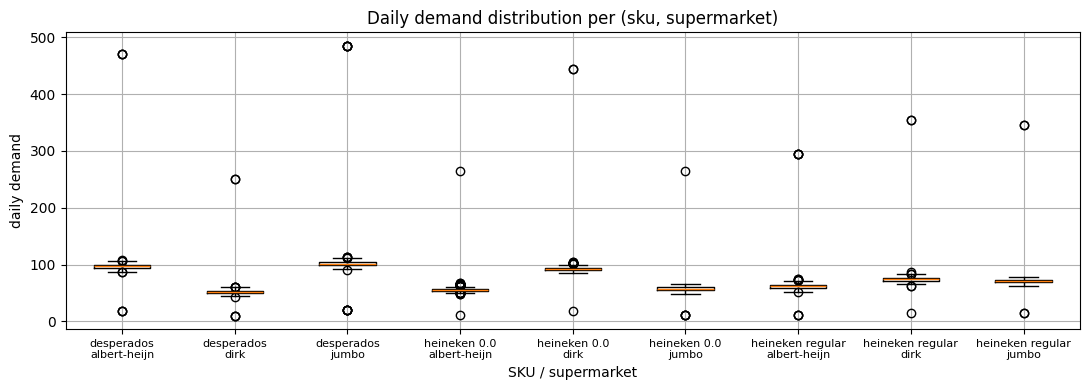

sku               supermarket 
desperados        albert-heijn    3
                  dirk            2
                  jumbo           5
heineken 0.0      albert-heijn    1
                  dirk            2
                  jumbo           1
heineken regular  albert-heijn    4
                  dirk            2
                  jumbo           2
Name: n_extreme, dtype: int64

In [10]:
# Outlier check per series. Count days more than 3 sigma above the group mean
# Promo-week peaks land in here too, so we keep them as this is a sanity count
fig, ax = plt.subplots(figsize=(11, 4))
labels, vals = [], []
for (sku, sm), g in merge_df.groupby(['sku', 'supermarket']):
    labels.append(f'{sku}\n{sm}')
    vals.append(g.demand.dropna().values)
ax.boxplot(vals, tick_labels=labels)
ax.set_title('Daily demand distribution per (sku, supermarket)')
ax.set_xlabel('SKU / supermarket')
ax.set_ylabel('daily demand')
plt.xticks(fontsize=8)
plt.tight_layout(); plt.show()

# z-score per row against its own (sku, supermarket) group's mean and std
g = merge_df.groupby(['sku', 'supermarket'])['demand']
z = (merge_df['demand'] - g.transform('mean')) / g.transform('std')

# Count of days > 3 sigma above the mean, per series
merge_df.assign(extreme=z > 3).groupby(['sku', 'supermarket'])['extreme'].sum().rename('n_extreme')

In [11]:
# Duplicates on (date, sku, supermarket)
print("No. of duplicates on (date, sku, supermarket):", merge_df.reset_index().duplicated(subset=['date', 'sku', 'supermarket']).sum())

No. of duplicates on (date, sku, supermarket): 0


In [12]:
# Column data types check
print(merge_df.dtypes)

demand         float64
sku             object
supermarket     object
promotion         bool
dtype: object


In [13]:
# Impute demand column, confirm nulls are gone and the per-group mean/std didn't shift much
merge_df_clean = clean_demand_per_group(merge_df.copy())
print('Nulls after cleaning:', merge_df_clean.demand.isnull().sum())
pd.concat([
    merge_df.groupby(['sku', 'supermarket']).demand.agg(['mean', 'std']).add_suffix('_raw'),
    merge_df_clean.groupby(['sku', 'supermarket']).demand.agg(['mean', 'std']).add_suffix('_clean'),
], axis=1).round(2)

Nulls after cleaning: 0


mean_raw  std_raw  mean_clean  std_clean
sku              supermarket                                           
desperados       albert-heijn     97.83    21.96       97.57      20.55
                 dirk             52.32     9.96       52.31       9.29
                 jumbo           102.71    27.73      102.62      26.86
heineken 0.0     albert-heijn     55.61     7.43       55.58       7.12
                 dirk             92.89    16.30       92.73      15.65
                 jumbo            57.20     7.96       57.14       7.53
heineken regular albert-heijn     62.51    15.53       62.42      14.73
                 dirk             74.25    13.46       74.11      12.79
                 jumbo            71.42    12.95       71.85      16.95

### Part 1: Summary
Three years of daily demand `(2019-01-01 → 2021-12-30)` for 3 SKUs (`desperados`, `heineken 0.0`, `heineken regular`) across 3 supermarkets (`albert-heijn`, `dirk`, `jumbo`) i.e. 9 (SKU, supermarket) series, 1,095 days each, 9,855 rows total. Promotions - 15 start-dates, 7 days each, unevenly distributed (some pairs ran 4, two have none).

Daily grid is complete (no missing calendar days). About 11% of demand values were NaN, imputed using `bfill` plus a group-mean tail fallback approach which does not shift the per-group mean or std meaningfully. No duplicates. A handful of >3σ outliers per series, mostly aligned with promo weeks - kept in, not removed.

### Part 2: Exploration
The business wants to predict the demand for each SKU per supermarket _eight weeks in advance_. Perform any kind of explorative analysis that provides initial insights to answer this question historically. You are free to do any kind of analysis, but try to converge back to the business question at the end. 

Your final result should cover two main aspects:
1. You can report back some answers about demand to the business
2. You have initial understanding of the features that affect demand, to create a model next.

In [14]:
# Aggregate to weekly
weekly_df = aggregate_to_weekly(merge_df_clean)
weekly_df.head()

,sku,supermarket,demand,promotion,n_days
date,,,,,
2019-01-06,desperados,albert-heijn,554.0,False,6
2019-01-13,desperados,albert-heijn,635.0,False,7
2019-01-20,desperados,albert-heijn,637.0,False,7
2019-01-27,desperados,albert-heijn,636.0,False,7
2019-02-03,desperados,albert-heijn,1013.0,False,7


In [15]:
# Print the size of weekly_df
print('Rows:', weekly_df.shape[0])
# Promo vs non-promo per (sku, supermarket)
print("\nPromo counts per (sku, supermarket):")
print(weekly_df.groupby(['sku', 'supermarket'])['promotion'].value_counts().unstack(fill_value=0))
# n_days distribution per (sku, supermarket)
print("\nN_days distribution per (sku, supermarket):")
print(weekly_df.groupby(['sku', 'supermarket'])['n_days'].value_counts().unstack(fill_value=0))

Rows: 1413

Promo counts per (sku, supermarket):
promotion                      False  True 
sku              supermarket               
desperados       albert-heijn    157      0
                 dirk            155      2
                 jumbo           149      8
heineken 0.0     albert-heijn    149      8
                 dirk            153      4
                 jumbo           156      1
heineken regular albert-heijn    153      4
                 dirk            155      2
                 jumbo           157      0

N_days distribution per (sku, supermarket):
n_days                         4  6    7
sku              supermarket            
desperados       albert-heijn  1  1  155
                 dirk          1  1  155
                 jumbo         1  1  155
heineken 0.0     albert-heijn  1  1  155
                 dirk          1  1  155
                 jumbo         1  1  155
heineken regular albert-heijn  1  1  155
                 dirk          1  1  155
            

In [16]:
# Drop the boundary partial-week buckets (1 leading 6-day row + 1 trailing 4-day row per series)
# so downstream stats see only full 7-day weeks
n_partial = (weekly_df['n_days'] != 7).sum()
weekly_df = weekly_df[weekly_df['n_days'] == 7].drop(columns='n_days').copy()
print('Partial weeks dropped:', n_partial)
print('\nShape of weekly_df:', weekly_df.shape)
weekly_df.head()

Partial weeks dropped: 18

Shape of weekly_df: (1395, 4)


,sku,supermarket,demand,promotion
date,,,,
2019-01-13,desperados,albert-heijn,635.0,False
2019-01-20,desperados,albert-heijn,637.0,False
2019-01-27,desperados,albert-heijn,636.0,False
2019-02-03,desperados,albert-heijn,1013.0,False
2019-02-10,desperados,albert-heijn,644.0,False


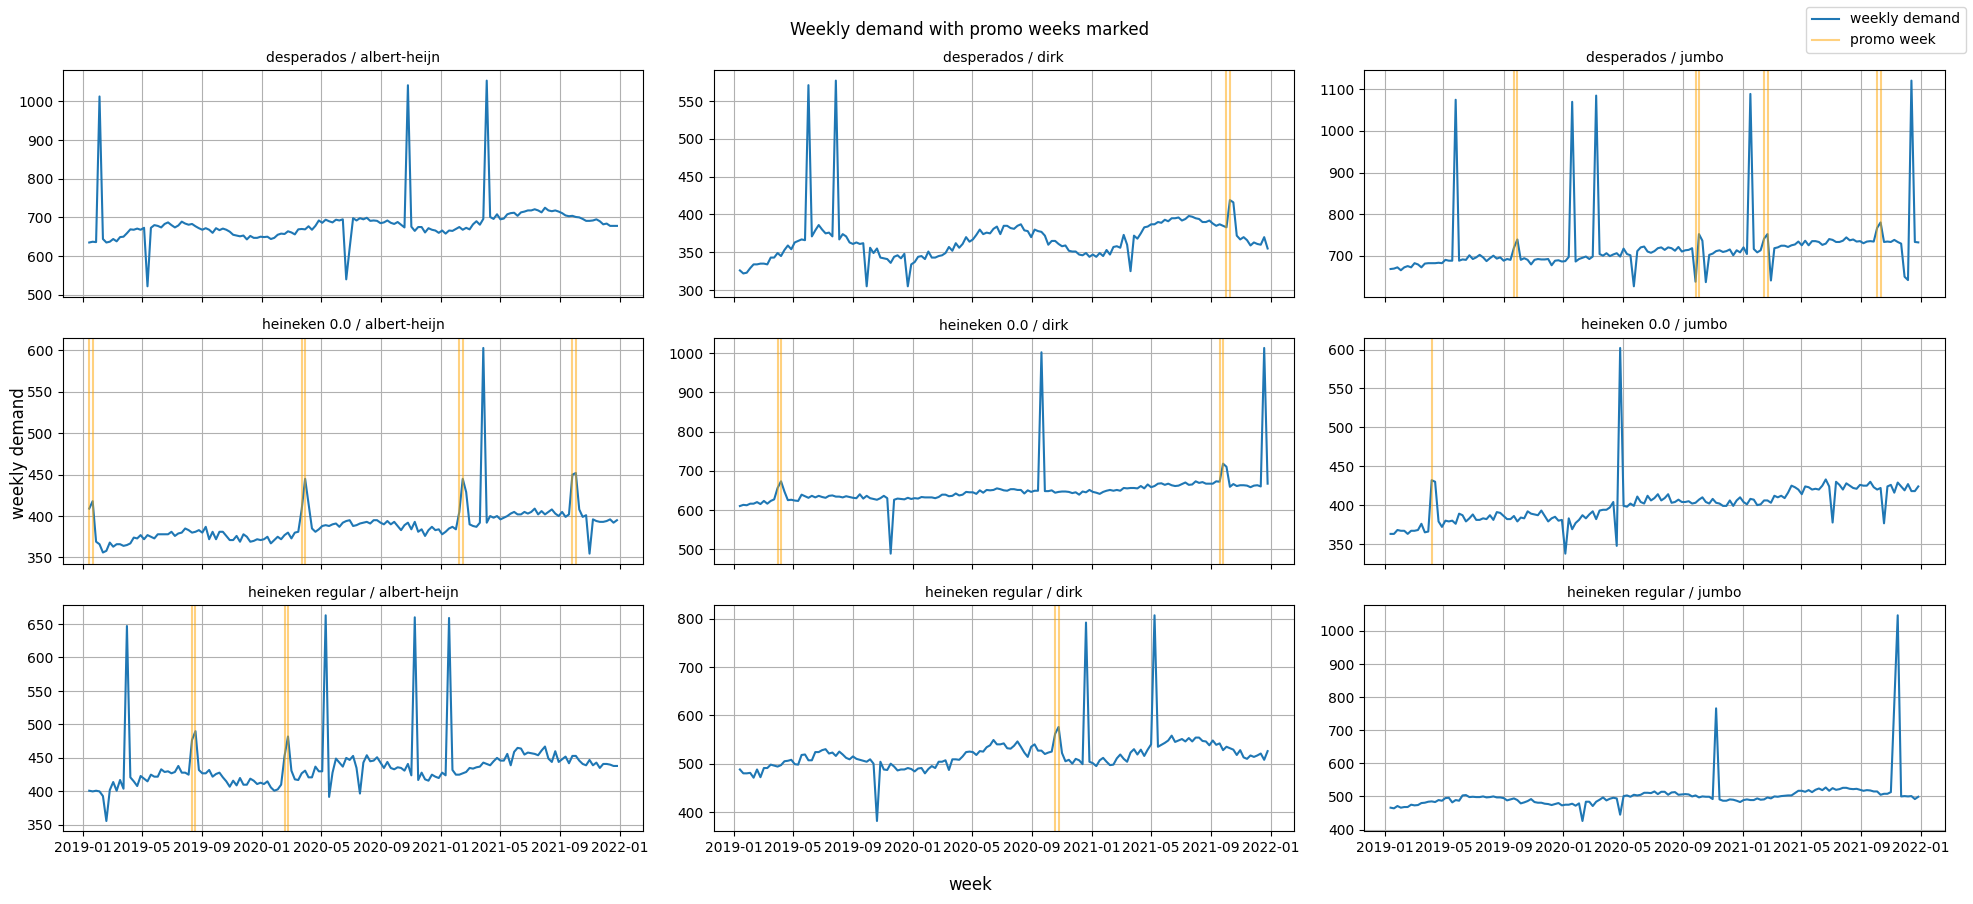

In [17]:
# Weekly demand per series. Vertical orange lines mark promo weeks.
fig, axes = plt.subplots(3, 3, figsize=(20, 9), sharex=True, sharey=False)
for ax, ((sku, sm), g) in zip(axes.flat, weekly_df.groupby(['sku', 'supermarket'])):
    ax.plot(g.index, g.demand)
    for d in g.index[g.promotion]:
        ax.axvline(d, color='orange', alpha=0.5)
    ax.set_title(f'{sku} / {sm}', fontsize=10)

fig.legend(
    handles=[
        Line2D([0], [0], color='tab:blue', label='weekly demand'),
        Line2D([0], [0], color='orange', alpha=0.5, label='promo week'),
    ],
    loc='upper right',
)
fig.suptitle('Weekly demand with promo weeks marked')
fig.supxlabel('week')
fig.supylabel('weekly demand')
plt.tight_layout()
plt.show()

In [18]:
# Per-series scale and steadiness. CV (= std/mean)
(weekly_df.groupby(['sku', 'supermarket'])['demand']
    .agg(['mean', 'std', 'min', 'max'])
    .assign(cv_pct=lambda d: (100 * d['std'] / d['mean']).round(1))
    .round(1))

mean   std    min     max  cv_pct
sku              supermarket                                     
desperados       albert-heijn  683.1  56.8  521.6  1054.0     8.3
                 dirk          366.4  31.4  305.0   577.0     8.6
                 jumbo         718.6  72.3  626.4  1121.0    10.1
heineken 0.0     albert-heijn  389.2  23.8  354.6   603.0     6.1
                 dirk          649.2  46.2  488.6  1013.0     7.1
                 jumbo         400.2  25.5  337.6   602.0     6.4
heineken regular albert-heijn  437.2  40.6  355.8   663.0     9.3
                 dirk          519.0  39.6  381.4   807.0     7.6
                 jumbo         503.1  56.5  425.8  1047.0    11.2

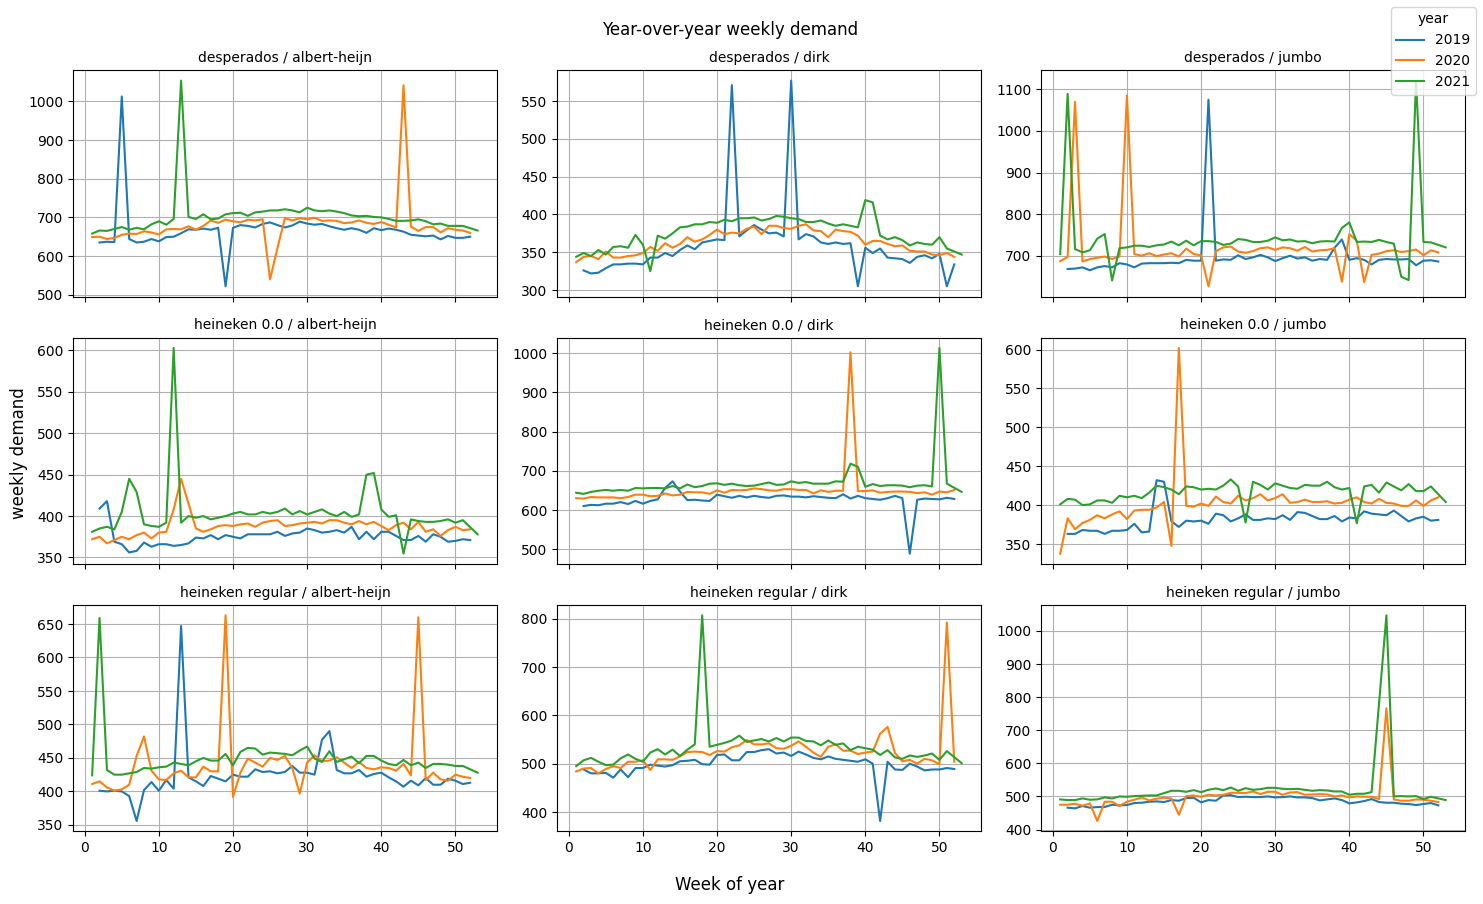

In [19]:
# Year-over-year overlay
yoy = weekly_df.assign(year=weekly_df.index.year, week=weekly_df.index.isocalendar().week.astype(int))

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for ax, ((sku, sm), g) in zip(axes.flat, yoy.groupby(['sku', 'supermarket'])):
    for yr, gg in g.groupby('year'):
        gg = gg.sort_values('week')
        ax.plot(gg.week, gg.demand, label=str(yr))
    ax.set_title(f'{sku} / {sm}', fontsize=10)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='year')

fig.suptitle('Year-over-year weekly demand')
fig.supxlabel('Week of year')
fig.supylabel('weekly demand')
plt.tight_layout()
plt.show()

In [20]:
# Year-on-year mean weekly demand. Tells us how much the baseline drifts year-to-year.
yoy_means = (weekly_df.assign(year=weekly_df.index.year)
    .groupby(['sku', 'supermarket', 'year'])['demand'].mean()
    .unstack('year').round(0))
yoy_means['2020_vs_2019_%'] = ((yoy_means[2020] / yoy_means[2019]) - 1).mul(100).round(1)
yoy_means['2021_vs_2020_%'] = ((yoy_means[2021] / yoy_means[2020]) - 1).mul(100).round(1)
yoy_means

year                            2019   2020   2021  2020_vs_2019_%  \
sku              supermarket                                         
desperados       albert-heijn  667.0  680.0  703.0             1.9   
                 dirk          359.0  363.0  376.0             1.1   
                 jumbo         695.0  719.0  741.0             3.5   
heineken 0.0     albert-heijn  375.0  388.0  404.0             3.5   
                 dirk          627.0  651.0  669.0             3.8   
                 jumbo         381.0  402.0  417.0             5.5   
heineken regular albert-heijn  424.0  439.0  449.0             3.5   
                 dirk          499.0  524.0  533.0             5.0   
                 jumbo         485.0  499.0  524.0             2.9   

year                           2021_vs_2020_%  
sku              supermarket                   
desperados       albert-heijn             3.4  
                 dirk                     3.6  
                 jumbo                    3.1  
heineken 0.0     albert-heijn             4.1  
                 dirk                     2.8  
                 jumbo                    3.7  
heineken regular albert-heijn             2.3  
                 dirk                     1.7  
                 jumbo                    5.0

In [21]:
# Promo uplift per series
uplift = (
    weekly_df.groupby(['sku', 'supermarket', 'promotion']).demand.mean()
    .unstack('promotion').rename(columns={False: 'non_promo', True: 'promo'})
)
uplift['uplift_%'] = ((uplift['promo'] / uplift['non_promo']) - 1) * 100
uplift['n_promo_weeks'] = (
    weekly_df[weekly_df.promotion].groupby(['sku', 'supermarket']).size()
    .reindex(uplift.index).fillna(0).astype(int)
)
uplift.round(2)

promotion                      non_promo   promo  uplift_%  n_promo_weeks
sku              supermarket                                             
desperados       albert-heijn     683.15     NaN       NaN              0
                 dirk             365.98  401.00      9.57              2
                 jumbo            717.65  735.92      2.55              8
heineken 0.0     albert-heijn     387.02  429.00     10.85              8
                 dirk             648.40  679.75      4.83              4
                 jumbo            399.97  432.00      8.01              1
heineken regular albert-heijn     436.18  475.50      9.01              4
                 dirk             518.37  569.00      9.77              2
                 jumbo            503.10     NaN       NaN              0

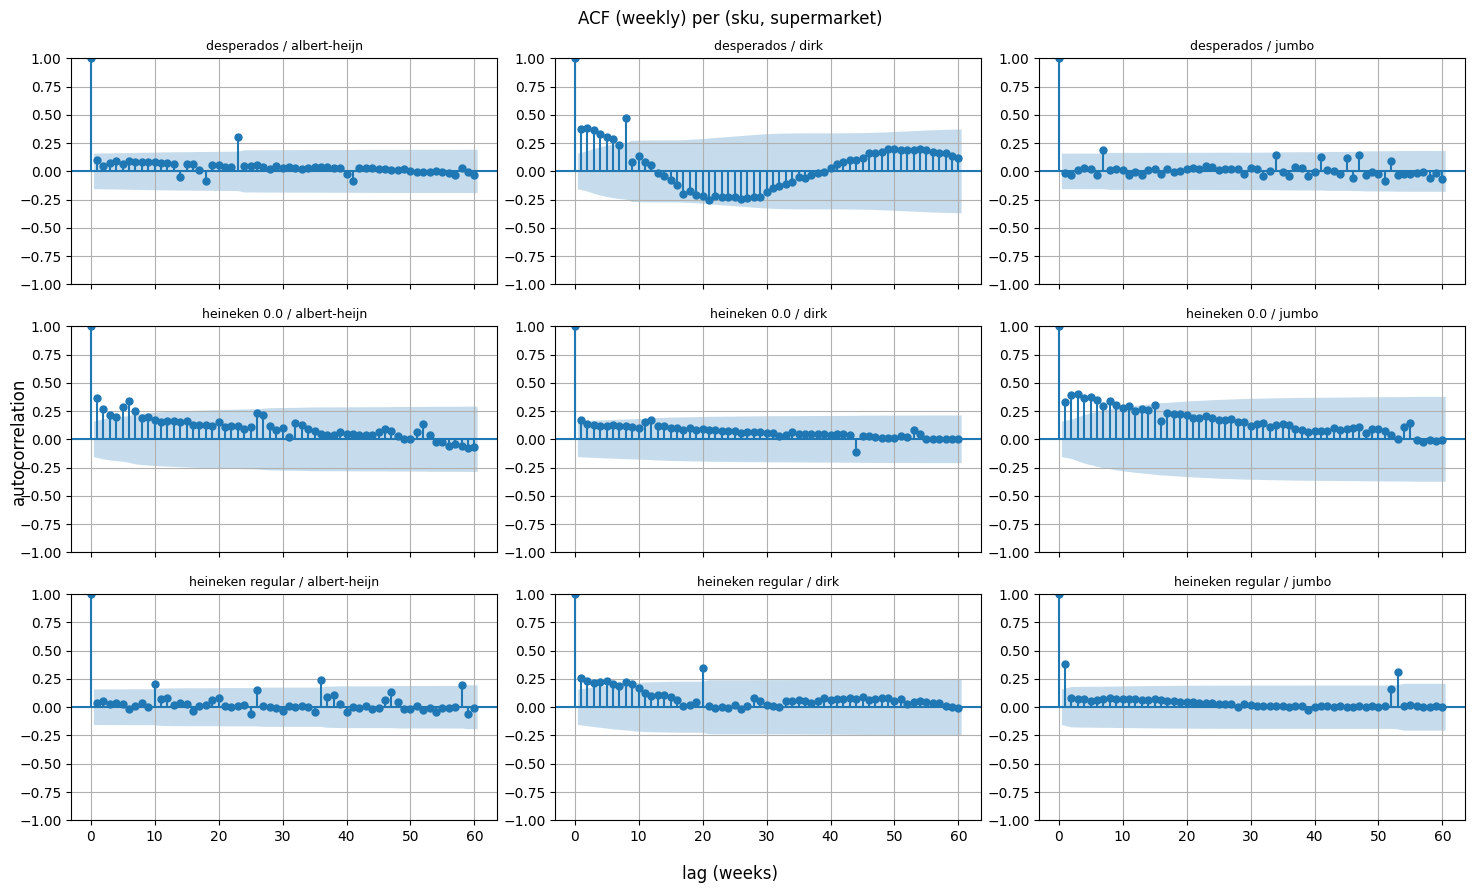

In [22]:
# ACF for every series
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for ax, ((sku, sm), g) in zip(axes.flat, weekly_df.groupby(['sku', 'supermarket'])):
    s = g.demand.asfreq('W').dropna()
    plot_acf(s, lags=60, ax=ax)
    ax.set_title(f'{sku} / {sm}', fontsize=9)
fig.suptitle('ACF (weekly) per (sku, supermarket)')
fig.supxlabel('lag (weeks)')
fig.supylabel('autocorrelation')
plt.tight_layout(); plt.show()

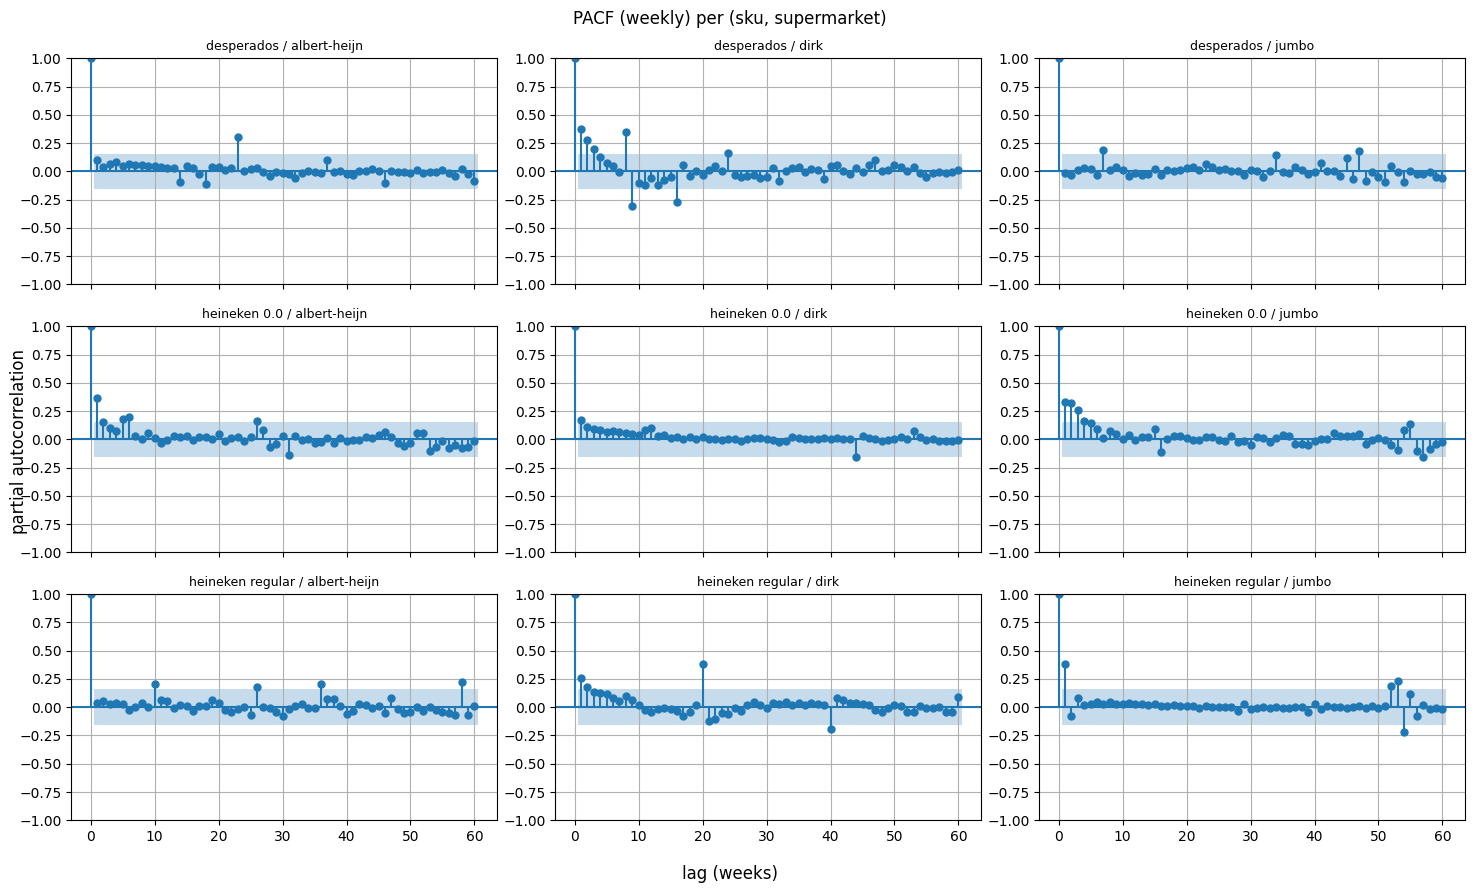

In [23]:
# PACF for every series
fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
for ax, ((sku, sm), g) in zip(axes.flat, weekly_df.groupby(['sku', 'supermarket'])):
    s = g.demand.asfreq('W').dropna()
    plot_pacf(s, lags=60, ax=ax, method='ywm')
    ax.set_title(f'{sku} / {sm}', fontsize=9)
fig.suptitle('PACF (weekly) per (sku, supermarket)')
fig.supxlabel('lag (weeks)')
fig.supylabel('partial autocorrelation')
plt.tight_layout(); plt.show()

In [24]:
# ACF at multiple lags per series
lags = [2, 5, 8, 16, 32, 52]
rows = []
for (sku, sm), g in weekly_df.groupby(['sku', 'supermarket']):
    s = g['demand'].asfreq('W').dropna()
    a = acf(s, nlags=max(lags))
    rows.append({'sku': sku, 'supermarket': sm, **{f'lag_{L}': round(a[L], 2) for L in lags}})

acf_table = pd.DataFrame(rows).set_index(['sku', 'supermarket'])
acf_table

lag_2  lag_5  lag_8  lag_16  lag_32  lag_52
sku              supermarket                                              
desperados       albert-heijn   0.05   0.06   0.09    0.07    0.03   -0.00
                 dirk           0.38   0.31   0.47   -0.12   -0.13    0.19
                 jumbo         -0.03   0.02   0.01   -0.02   -0.04    0.09
heineken 0.0     albert-heijn   0.26   0.28   0.19    0.13    0.15    0.14
                 dirk           0.14   0.12   0.12    0.10    0.03    0.02
                 jumbo          0.39   0.37   0.34    0.16    0.15    0.04
heineken regular albert-heijn   0.06   0.03   0.04   -0.03    0.00   -0.03
                 dirk           0.24   0.23   0.22    0.06    0.00    0.03
                 jumbo          0.08   0.06   0.08    0.06    0.01    0.16

- `desperados/dirk` and `heineken 0.0/jumbo` keep meaningful short-memory all the way out to lag 8 (0.47 and 0.34). For these two pairs, recent demand is a real predictor of the value 8 weeks later.

- Three pairs (`desperados/albert-heijn`, `desperados/jumbo`, `heineken regular/albert-heijn`) sit near zero at every non-trivial lag.

- The rest sit in 0.1–0.3 at short lags and fade out by lag 16. Some autocorrelation, not a lot, gone by mid-range.

- Lag 52 is weak everywhere (-0.03 to 0.19). The "same week last year" signal exists but is small.

- `desperados/dirk` has negative correlations at lag 16 and lag 32 (−0.12 and −0.13). what's high in week t tends to be low about 4 months later.

### Part 2 summary

##### What we can tell the business about demand

- Demand at each (SKU, supermarket) is mostly stable ie week-to-week sits within about 6–11% of its own baseline.

- Year-on-year the baselines are drifting up slowly: 1–6% growth from 2019 to 2020 and another 2–5% to 2021, on every series.

- Promotion weeks lift demand by 5–11% on the seven pairs that have ever run one; two pairs (`desperados/albert-heijn` and `heineken regular/jumbo`) have no promo history at all.

##### Features the model should use

- The **promotion flag** for the target week is the single biggest driver and known forward so it goes in as an exogenous regressor (currently not provided in the dataset for future dates).

- **SKU and supermarket identity** - baselines differ by close to an order of magnitude, so the model has to condition on them.

- **Calendar position / Fourier annual seasonality** - captures the modest summer hump where it exists, fits near-zero where it doesn't.

- **Recent demand (lag features)** — useful at lag-8 on two pairs (`desperados/dirk` 0.47, `heineken 0.0/jumbo` 0.34); on the other seven the model has to rely on forward-known features rather than history (currently not available).